# Project 3B T126 - Water Pipe Failure Prediction

This notebook provides a short end-to-end demonstration of the final project workflow.

Detailed exploratory work, preprocessing logic, modelling functions, and evaluation utilities are stored in separate `.py` files under `src/` folder.

## 1. Dataset Review and Final Selection

Several candidate datasets were reviewed to determine which dataset was most suitable for supervised pipe failure modelling.

The review focused on:

- dataset size and structure
- availability of historical failure records
- ability to link break records to pipe assets
- suitability for flat machine learning workflows
- availability of environmental or soil information

In [2]:
from src.dataset_review import run_dataset_review, display_dataset_summary

review_results = run_dataset_review(
    melbourne_mains_path="data/raw/Melbourne/Water_Supply_Main_Pipelines.csv",
    melbourne_soil_path="data/raw/Melbourne/Soil-Readings-Melbourne.csv",
    netherlands_mains_path="data/raw/Netherlands/Netherlands_watermains.pickle",
    netherlands_breaks_path="data/raw/Netherlands/Netherlands_watermainbreaks.npy",
    kitchener_mains_path="data/raw/Kitchener/Kitchener_watermains.csv",
    kitchener_breaks_path="data/raw/Kitchener/Kitchener_watermainbreaks.csv",
    bozeman_path="data/raw/Bozeman/Bozeman_watermainbreaks.csv",
)

display_dataset_summary(review_results)

,dataset,rows,columns,missing_cells,duplicate_rows
0,Melbourne Water Mains,12680,37,155063,0
1,Melbourne Soil Readings,905562,7,2784,0
2,Netherlands Water Mains,10203,12,0,0
3,Netherlands Break History,10203,12,0,1901
4,Kitchener Water Mains,16163,27,43861,0
5,Kitchener Water Main Breaks,2994,37,43688,0
6,Bozeman Water Main Breaks,158,12,48,0


Original Netherlands break history shape:
(10203, 6, 2)

Kitchener join key check:
{'mains_key': True, 'breaks_key': True}


### 1.1 Dataset shortlist summary

The review output highlighted major differences between the shortlisted datasets in terms of scale, structure and modelling suitability.

The Kitchener datasets provided the strongest foundation for supervised modelling, containing 16,163 water main asset records and 2,994 historical break records. The matching identifiers (`WATMAINID` and `Related Asset ID`) also confirmed that break events could be linked directly back to pipe assets to create a pipe-level target variable.

The Netherlands dataset contained 10,203 records and relatively complete feature data, but the break history was stored in a sequence-based 3D array with shape `(10203, 6, 2)`, making it less suitable for the planned flat machine learning workflow.

The Bozeman dataset only contained 158 records, which was considered too small for reliable model training and evaluation.

The Melbourne datasets provided large-scale operational and environmental data, including 12,680 water main records and more than 900,000 soil monitoring records. However, no historical break labels were available for supervised learning.

### 1.2 Final dataset decision

The **Kitchener dataset** was selected as the final modelling dataset because it provides:

- water main asset information
- historical break records
- usable matching between break records and pipe assets
- enough structure to create a pipe-level supervised learning dataset

### 1.3 External soil dataset result

The Kitchener dataset does not include soil or environmental attributes. Because soil conditions may influence pipe deterioration, two external Canadian soil datasets were tested using GIS spatial joins:

1. Ontario Soil Survey Complex  
2. CANSIS / Soil Landscapes of Canada

In [5]:
from src.external_soil_testing import (
    run_external_soil_testing,
    display_soil_testing_summary,
)

soil_results = run_external_soil_testing(
    breaks_path="data/processed/kitchener_breaks_clean.csv",
    ontario_soil_path="data/raw/Ontario Soil Survey Complex/Soil_Survey_Complex.geojson",
    slc_shp_path="data/raw/CANSIS SLC/ca_all_slc_v3r2.shp",
    cmp_path="data/raw/CANSIS SLC/ca_all_slc_v3r2_cmp.dbf",
    snt_path="data/raw/Ontario Soil Survey Complex/soil_name_canada_v2r20231107.dbf",
    output_latlon_path="data/processed/kitchener_breaks_latlon.csv",
)

display_soil_testing_summary(soil_results)

Ontario Soil Survey Complex
Matched rows: 2994
Total rows: 2994
Match %: 100.0

Top Ontario soil names:


SOIL_NAME1
URBAN                       2943
WATERLOO FINE SANDY LOAM      23
BURFORD GRAVELLY LOAM          7
LISBON SANDY LOAM              7
WATER                          4
BUILT UP AREA                  3
ELMIRA LOAM                    2
FOX SANDY LOAM                 2
ST CLEMENTS SILT LOAM          1
CALEDON SANDY LOAM             1
Name: count, dtype: int64


Top Ontario texture values (%):


ATEXTURE1
NA     98.53
FSL     0.77
SL      0.37
GL      0.23
L       0.07
SIL     0.03
Name: proportion, dtype: float64


CANSIS / Soil Landscapes of Canada
Matched polygon rows: 2994
Unmatched polygon rows: 0
Match %: 100.0

Top CANSIS soil names:


SOILNAME
FOX         1718
BURFORD      701
WATERLOO     572
GUELPH         3
Name: count, dtype: int64


CANSIS drainage distribution:


DRAINAGE
W    2994
Name: count, dtype: int64


CANSIS texture distribution:


PMTEX1
VC    2991
M        3
Name: count, dtype: int64

#### Soil testing result

Both GIS spatial joins achieved 100% coverage, with all 2,994 Kitchener break records matched to soil polygons.

However, the Ontario Soil Survey Complex results were dominated by broad urban classifications, with 2,943 records labelled as `URBAN` and 98.53% of texture values recorded as `NA`.

The CANSIS dataset produced cleaner soil attributes, but the results still showed limited variation. Most records fell into only three soil groups (`FOX`, `BURFORD`, and `WATERLOO`), while drainage and texture values were almost constant across the dataset.

Therefore, the external soil datasets were not included as final modelling features because they did not provide sufficient pipe-level discriminatory value for the modelling stage.

## 2. Kitchener Preprocessing Workflow

This section demonstrates the final preprocessing pipeline used to convert the raw Kitchener mains and break datasets into a clean pipe-level dataset for modelling.

**Preprocessing steps**

- cleans the raw mains and break source tables
- removes weak or high-missing fields
- standardises date and key fields
- links break records to water main assets
- aggregates event-level break history to pipe level
- creates the target variable `has_break`
- derives final modelling features such as `pipe_age`
- exports the final model-ready dataset

**Main output**

The main file used for modelling is:

- `data/processed/kitchener_model_ready.csv`

### 2.1 Run pre-processing

In [9]:
from src.kitchener_preprocessing import (
    run_kitchener_preprocessing,
    display_kitchener_preprocessing_summary,
    plot_target_distribution,
)

kitchener_results = run_kitchener_preprocessing(
    mains_path="data/raw/Kitchener/Kitchener_watermains.csv",
    breaks_path="data/raw/Kitchener/Kitchener_watermainbreaks.csv",
    output_dir="data/processed",
    save_outputs=True,
    verbose=False,
)

display_kitchener_preprocessing_summary(kitchener_results)

Raw data
Raw mains shape: (16163, 27)
Raw breaks shape: (2994, 37)

After cleaning
Cleaned mains shape: (16163, 22)
Cleaned breaks shape: (2994, 18)

Asset matching
{'asset_match_rate_pct': 81.9, 'matched_break_rows': 2452, 'unmatched_break_rows': 542}

MAIN break filtering
MAIN breaks shape: (2922, 18)
Matched MAIN breaks shape: (2451, 18)

Final datasets
Pipe-level dataset shape: (16163, 26)
Pipe master dataset shape: (16163, 28)
Model-ready dataset shape: (16163, 20)

Target distribution
has_break
0    14929
1     1234
Name: count, dtype: int64

Target distribution (%)
has_break
0    92.37
1     7.63
Name: proportion, dtype: float64


#### Kitchener preprocessing result

The preprocessing pipeline converted 16,163 raw water main records and 2,994 raw break records into a clean pipe-level modelling dataset.

After removing weak or high-missing fields, the mains dataset was reduced from 27 to 22 columns, and the breaks dataset was reduced from 37 to 18 columns. The asset matching step achieved an 81.9% match rate, with 2,452 break records linked to water main assets. After filtering to MAIN breaks only, 2,451 matched MAIN break records were used for pipe-level aggregation.

The final model-ready dataset contains 16,163 pipe records and 20 columns. The target variable is imbalanced, with 14,929 pipes having no observed break and 1,234 pipes having at least one observed break, meaning only 7.63% of pipes are positive cases.

### 2.2 Preview model-ready data

The model-ready dataset is the final processed Kitchener dataset used for model development. It contains one row per pipe and includes cleaned asset-level predictors plus the target variable `has_break`.

In [12]:
model_ready_df = kitchener_results["model_ready_df"]
display(model_ready_df.head())

,pressure_zone,category,pipe_size,material,lined,lined_material,acquisition,ownership,bridge_main,criticality,rel_cleaning_area,rel_cleaning_subarea,undersized,shallow_main,condition_score,oversized,cleaned,shape__length,has_break,pipe_age
0,KIT 6,TREATED,450,DI,0,NONE,DONATED,DUAL CITY AND REGION,0,6.0,6,8,0,0,8.50,0,0,34.210563,0,47.2
1,KIT 4,TREATED,300,DI,0,NONE,PURCHASED,REGION,0,7.0,1,4,0,0,8.50,0,0,0.355118,0,57.7
2,KIT 6,TREATED,450,DI,0,NONE,DONATED,DUAL CITY AND REGION,0,7.0,6,8,0,0,6.10,0,1,67.852910,1,47.2
3,KIT 6,TREATED,450,DI,0,NONE,DONATED,DUAL CITY AND REGION,0,6.0,6,8,0,0,4.58,0,1,7.039328,1,47.2
4,KIT 6,TREATED,450,DI,0,NONE,DONATED,DUAL CITY AND REGION,0,6.0,6,8,0,0,8.50,0,1,14.956131,0,47.2


### 2.3 Check class balance

The target distribution is checked before modelling because pipe failure prediction is an imbalanced classification problem.

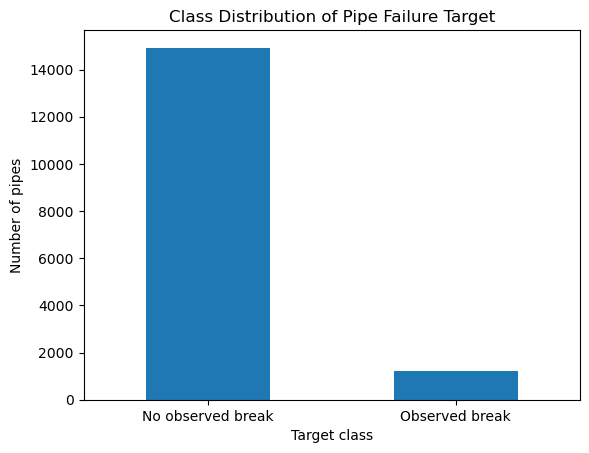

In [14]:
plot_target_distribution(kitchener_results["pipe_df"])

The target variable is highly imbalanced. Only 1,234 out of 16,163 pipes have an observed historical break, representing 7.63% of all records. This means accuracy alone is not enough for model evaluation, so later model comparison uses metrics such as precision, recall, F1-score, ROC-AUC and PR-AUC.

## 3. Kitchener - Model Development and Comparision

This section demonstrates the modelling workflow using the processed Kitchener pipe-level dataset.

The model-ready dataset from the preprocessing stage is used to train and compare three supervised classification models:

- Logistic Regression
- Random Forest
- XGBoost

### 3.1 Random Forest Modelling

This section demonstrates the Random Forest modelling workflow using the processed Kitchener model-ready dataset.

Random Forest was included because it can capture non-linear relationships between pipe attributes and historical break risk. It also provides feature importance values, which are useful for interpreting key risk drivers and supporting the later Melbourne adaptation stage.

In [17]:
from src.kitchener_random_forest import (
    run_random_forest_workflow,
    display_random_forest_summary,
    plot_feature_importance,
    plot_confusion_matrix
)

rf_results = run_random_forest_workflow(
    data_path="data/processed/kitchener_model_ready.csv",
    target_col="has_break",
    random_state=42,
)

display_random_forest_summary(rf_results)

Data split
Train shape: (11314, 19)
Validation shape: (2424, 19)
Test shape: (2425, 19)

Validation metrics
roc_auc: 0.991
pr_auc: 0.9678
precision: 0.9713
recall: 0.9135
f1: 0.9415

Test metrics
roc_auc: 0.9906
pr_auc: 0.9596
precision: 0.9508
recall: 0.9405
f1: 0.9457

Test confusion matrix
[[2231    9]
 [  11  174]]

Top 10 feature importance


,feature,importance
0,num__condition_score,0.465971
1,num__shape__length,0.164188
2,num__pipe_age,0.101289
3,cat__material_CI,0.043767
4,cat__material_PVC,0.033200
5,num__pipe_size,0.021305
6,num__rel_cleaning_area,0.016968
7,num__criticality,0.014846
8,cat__pressure_zone_KIT 4,0.010347
9,cat__material_DI,0.009545


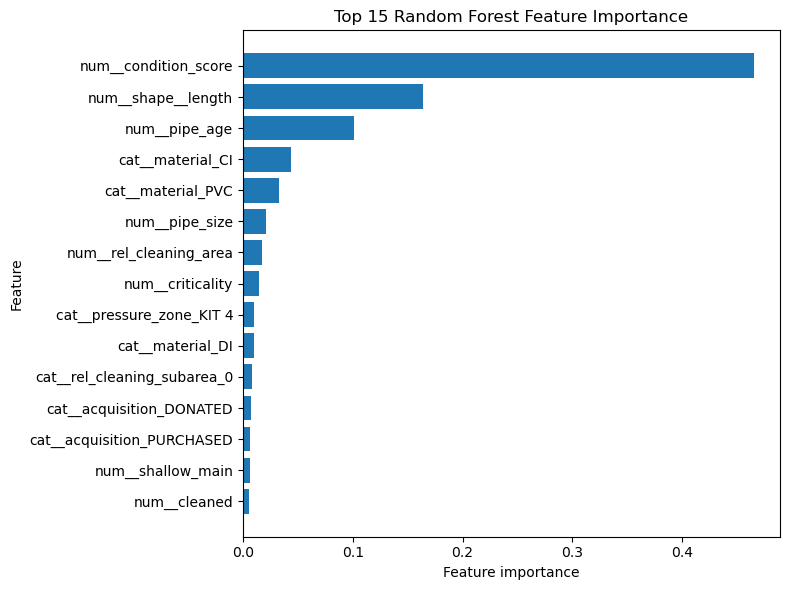

In [18]:
plot_feature_importance(rf_results, top_n=15)

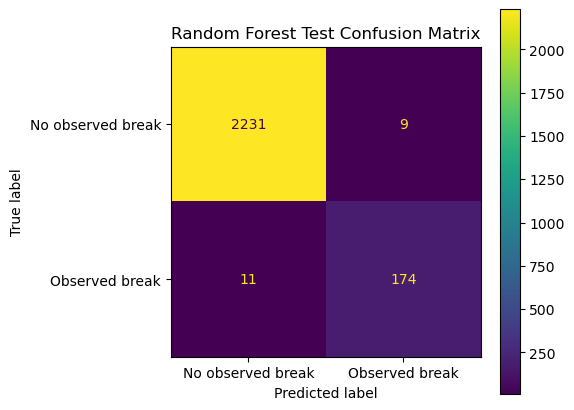

In [19]:
plot_confusion_matrix(rf_results)

#### Random Forest result

The Random Forest model performed strongly on both validation and test data. The test result achieved ROC-AUC of 0.9906, PR-AUC of 0.9596, precision of 0.9508, recall of 0.9405 and F1-score of 0.9457.

The test confusion matrix showed 2,231 true negatives, 174 true positives, 9 false positives and 11 false negatives. This indicates the model was able to identify most observed break cases while keeping false alarms low.

Feature importance suggests that `condition_score` was the strongest predictor, followed by `shape__length`, `pipe_age`, and material-related features such as `CI` and `PVC`. These results indicate that pipe condition, physical size/length, age and material were the main drivers of predicted failure risk.

### 3.2 XGBoost Modelling

This section runs the XGBoost model using the same processed Kitchener model-ready dataset and the same 70/15/15 train, validation and test split.

XGBoost was included because it is a strong gradient boosting model that can capture non-linear patterns and feature interactions. It also supports class weighting and native categorical handling, which is useful for the imbalanced pipe failure dataset.

In [22]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [31]:
import importlib
import src.kitchener_xgboost as kxgb

importlib.reload(kxgb)

from src.kitchener_xgboost import (
    run_xgboost_workflow,
    display_xgboost_summary,
    plot_confusion_matrix,
    plot_feature_importance,
)

xgb_results = kxgb.run_xgboost_workflow(
    data_path="data/processed/kitchener_model_ready.csv",
    target_col="has_break",
    random_state=42,
)

kxgb.display_xgboost_summary(xgb_results)

Data split
Train shape: (11314, 19)
Validation shape: (2424, 19)
Test shape: (2425, 19)

Model settings
Scale pos weight: 12.09
Fixed tuned parameters: {'max_depth': 6, 'learning_rate': 0.04110359181702955, 'subsample': 0.7514526781869276, 'colsample_bytree': 0.6976106662148625, 'min_child_weight': 7, 'gamma': 1.9395005517710073}

Test metrics
roc_auc: 0.9899
pr_auc: 0.9614
precision: 0.9133
recall: 0.9676
f1: 0.9396

Test confusion matrix
[[2223   17]
 [   6  179]]

Top 10 feature importance


,feature,importance
0,condition_score,169.882584
1,material,34.952023
2,shape__length,28.668089
3,pipe_age,18.506891
4,rel_cleaning_subarea,14.014015
5,pressure_zone,9.589307
6,rel_cleaning_area,9.438110
7,shallow_main,8.608771
8,pipe_size,8.266403
9,acquisition,7.174965


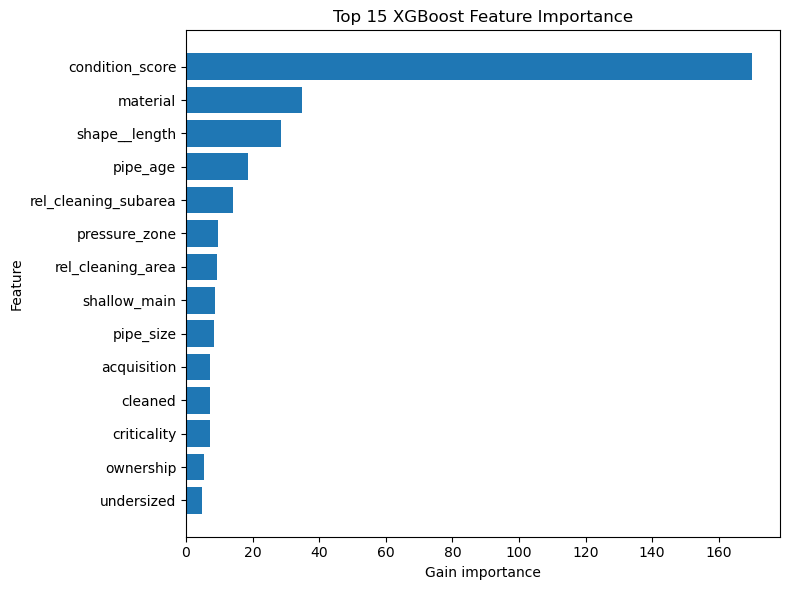

In [35]:
plot_feature_importance(xgb_results, top_n=15)

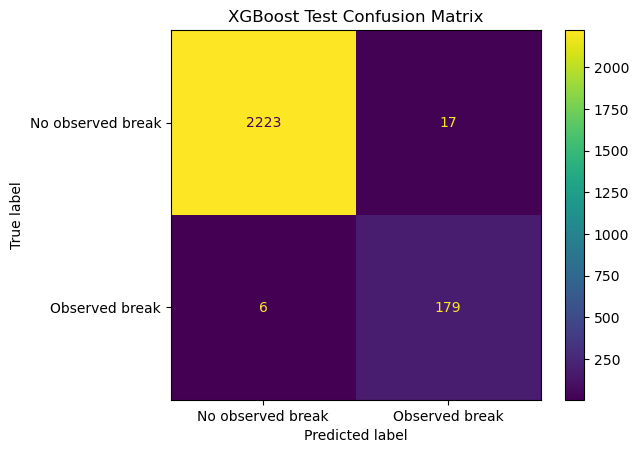

In [33]:
plot_confusion_matrix(xgb_results)

### XGBoost result

The XGBoost model achieved strong test performance, with ROC-AUC of 0.9899, PR-AUC of 0.9614, precision of 0.9133, recall of 0.9676 and F1-score of 0.9396.

The confusion matrix shows 2,223 true negatives and 179 true positives, with 17 false positives and 6 false negatives. Compared with Random Forest, XGBoost captured slightly more break cases, but produced more false positives.

The feature importance results show that `condition_score` was the strongest predictor, followed by `material`, `shape__length`, `pipe_age`, and cleaning or network-related variables. This is consistent with the Random Forest findings and supports using asset condition, material, length and age as key risk drivers for the Melbourne adaptation stage.

## 4. Melbourne Water Main Data Preprocessing

This section prepares the raw Melbourne water main dataset for the Melbourne risk identification stage.

The preprocessing workflow includes:
- Selecting relevant asset-level columns from the raw dataset
- Cleaning missing and inconsistent values (e.g. invalid lengths, widths, future dates)
- Converting date fields to proper datetime format
- Engineering key features such as `PIPE_AGE`, `HAS_RELINED`, and `YEARS_SINCE_RELINED`
- Creating data quality flags (e.g. missing construction date, missing relined date)
- Standardising categorical fields and filling non-critical missing values
- Removing duplicate records

The output is a cleaned, pipe-level dataset ready for the finding adaptation stage.

In [ ]:
from src.melbourne_preprocessing import build_melbourne_cleaned_dataset

melbourne_cleaned = build_melbourne_cleaned_dataset()

display(melbourne_cleaned.head())
print(melbourne_cleaned.shape)

### Melbourne Preprocessing Output Summary

The preprocessing pipeline produced a cleaned Melbourne dataset with **12,677 rows and 24 columns** after removing exact duplicate rows.

Most fields needed for finding adaptation are complete after cleaning, including material, pipe length, pipe width, relining indicators, service status, and operational context.

Some fields still contain missing values:
- `PIPE_AGE` / `DATE_OF_CONSTRUCTION`: 901 missing records
- `DATE_RELINED`: 7,537 missing records
- `DATE_LAST_UPDATED`: 53 missing records

These are acceptable for the next stage because missing construction and relining dates are captured using flags such as `MISSING_CONSTRUCTION_DATE` and `MISSING_RELINED_DATE`.

`COMPKEY` should be used as the main pipe/segment identifier because `ASSET_ID` is repeated across many records.

In [ ]:
print("Shape:", melbourne_cleaned.shape)
print("\nMissing values:")
display(melbourne_cleaned.isna().sum().sort_values(ascending=False))

print("\nDuplicate rows:", melbourne_cleaned.duplicated().sum())
print("Unique COMPKEY:", melbourne_cleaned["COMPKEY"].nunique())
print("Unique ASSET_ID:", melbourne_cleaned["ASSET_ID"].nunique())